<a href="https://colab.research.google.com/github/lourdesmaria-mvg/Practicas_procesos/blob/main/Copia_de_PAS_PRADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio: simular y visualizar PAS

Objetivo final: completar un cuaderno como este para generar todas las imágenes del PAS de las diapositivas, subirlo a vuestro perfil de GitHub, y compartirlo conmigo. (Para final de la semana que viene, fecha a concretar).

Sobre el uso de IA generativa / LLMs:
* Se os anima a usarla para desatascaros en pasos pequeños y muy concretos (que te explique cómo hacer la media por filas de una matriz; que te explique cómo funciona cierta función que el profesor ha mencionado etc.).
* Pero no tiene sentido usarla para pasos excesivamente grandes en los que perdéis el control de qué se está haciendo (por ejemplo, decirle que te genere las figuras directamente).
* El verdadero objetivo final es entender el proceso, desarrollar habilidades de planificación, y asimilar las estructuras de pensamiento matemático-computacional subyacentes. Estáis en etapa formativa, no en etapa productiva.
* Como posible control, yo podré convocaros en clase o tutoría para que me expliquéis cómo funciona vuestro código.
* Pero, al fin y al cabo, lo que más está en juego es vuestra formación: adquirir valor añadido (ser capaz de desarrollar unas estructuras mentales que os permitan resolver problemas complejos en el futuro, problemas que quizás sean diferentes a los que hay hoy día), o ser una pieza de poco valor añadido y fácilmente sustituible (un “usuario de IA”).

Se recomienda que avancéis de aquí al lunes. Probablemente le dediquemos lunes y martes, y ya después pasemos a otra cosa. Y tendréis que entregarlo a final de semana (fecha a concretar).

Si escribís sobre este notebook que os comparto, vuestros cambios no se guardarán (porque solo tenéis permisos de lectura). Tendréis que crear una copia vuestra ("Archivo > Guardar una copia en Drive").

---------------------------------------------------------------

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

## El núcleo: implementar una función para simular el PAS

Define una función `simular_PAS` que reciba tres argumentos:
* p: este es el parámetro principal del PAS. Es la probabilidad de tomar el valor 1 en cada paso (y la probabilidad de tomar el -1 sería $1-p$). Es un valor entre 0 y 1.
* n: el número de pasos a simular para cada trayectoria. Un número natural.
* reps: el número de trayectorias a simular. Un número natural.

La función debe devolver un array de numpy con dimensionalidad `(reps, n)`, que contenga los valores del PAS en cada paso para cada trayectoria.  

Esqueleto de la función a construir (a completar por vosotros):

Primero piensa durante un rato cómo lo harías, e intenta completar la función. Si te quedas atrancado/a, puedes mirar la pista de abajo. **Importante**: lo fundamental de la frase anterior es "*si te quedas atrancado/a*", es decir, debes pensarlo un rato por tu cuenta. De lo contrario, si vas directo a la solución, no se produce ningún aprendizaje y no te sirve de nada.

----------------------------------------

In [ ]:
def simular_PAS(p,n,reps):
  #Input:
  #p: probabilidad en cada paso. Será un valor entre 0 y 1
  #n: número de pasos
  #reps: número de trayectorias
  #Output:
  #output: array de dimensión (reps, n+1)

  #Definimos la matriz con todo ceros para que guarde los pasos
  pasos = np.zeros((reps, n + 1))

  #Generamos los pasos que serán +1 o -1
  pasos[:, 1:] = np.random.choice([1, -1], size=(reps, n), p=[p, 1-p])

  #Calculamos la posición en cada instante con la suma acumulada de los pasos
  trayectorias = np.cumsum(pasos, axis=1)

  return trayectorias

In [ ]:
def graficar_PAS(trayectorias, p, n, reps):
    #Esta función toma los datos y los parámetros para dibujar
    plt.figure(figsize=(10, 5))

    #Graficamos la traspuesta para que cada fila sea una línea
    plt.plot(trayectorias.T)

    plt.title(f"Simulación con p={p}, n={n} y {reps} caminos")
    plt.xlabel("Tiempo (t)")
    plt.ylabel("Posición ($X_t$)")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.axhline(0, color='black', linewidth=1) # Línea en el eje 0
    plt.show()

Pista:

Más adelante.


## Visualización 1: diferentes trayectorias del PAS (sin media ni desviación típica teóricas)

Escribir código para crear las imágenes de las diapositivas 16 ($p=0.5$), 17 ($p=0.6$) y 18 ($p=0.4$) del tema 1.

In [ ]:
#DIAPOSITIVA 16
trayectorias = simular_PAS(0.5,500,5)
trayectorias

array([[ 0.,  1.,  0., ..., 20., 19., 18.],
       [ 0., -1.,  0., ...,  2.,  1.,  0.],
       [ 0.,  1.,  0., ...,  0., -1.,  0.],
       [ 0., -1., -2., ..., -8., -9., -8.],
       [ 0., -1.,  0., ..., 28., 29., 30.]])

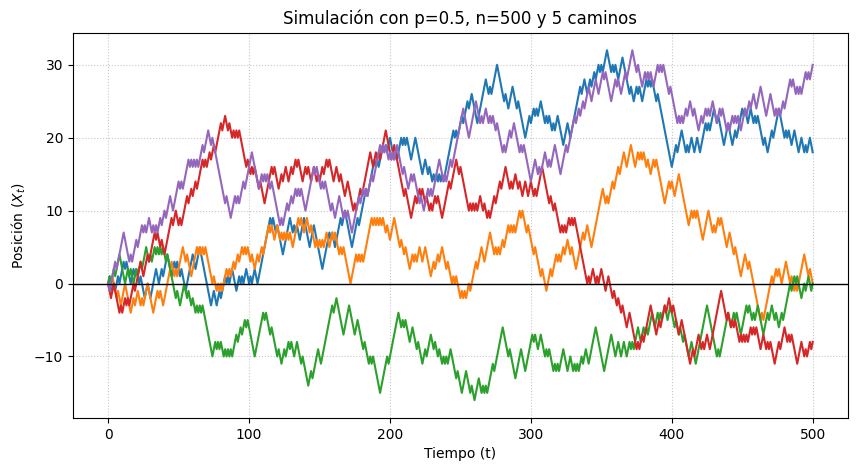

In [ ]:
graficar_PAS(trayectorias, 0.5, 500, 5)

In [ ]:
#DIAPOSITIVA 17
trayectorias = simular_PAS(0.6,500,5)
trayectorias

array([[  0.,  -1.,   0., ...,  88.,  89.,  90.],
       [  0.,  -1.,  -2., ..., 110., 111., 110.],
       [  0.,  -1.,  -2., ...,  90.,  91.,  92.],
       [  0.,  -1.,   0., ...,  90.,  89.,  90.],
       [  0.,   1.,   0., ..., 124., 125., 126.]])

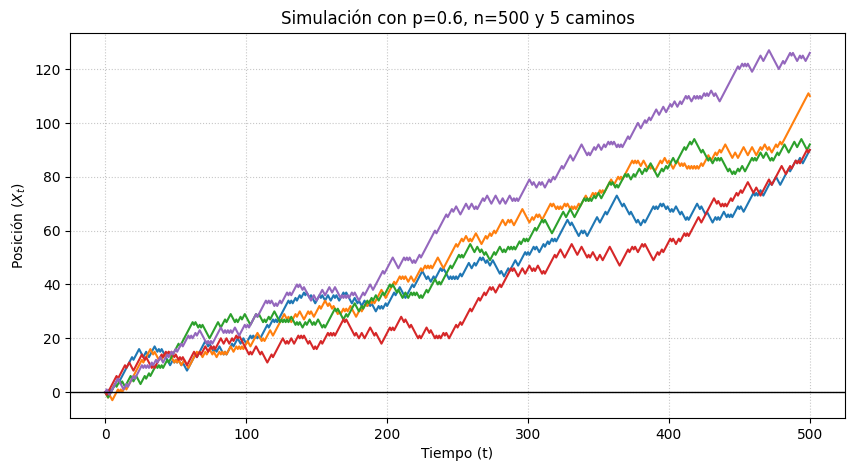

In [ ]:
graficar_PAS(trayectorias, 0.6, 500, 5)

In [ ]:
#DIAPOSITIVA 18
trayectorias = simular_PAS(0.4,500,5)
trayectorias

array([[   0.,    1.,    2., ...,  -88.,  -87.,  -88.],
       [   0.,   -1.,    0., ..., -134., -135., -136.],
       [   0.,    1.,    0., ..., -114., -115., -116.],
       [   0.,   -1.,    0., ..., -160., -159., -158.],
       [   0.,   -1.,   -2., ..., -106., -107., -108.]])

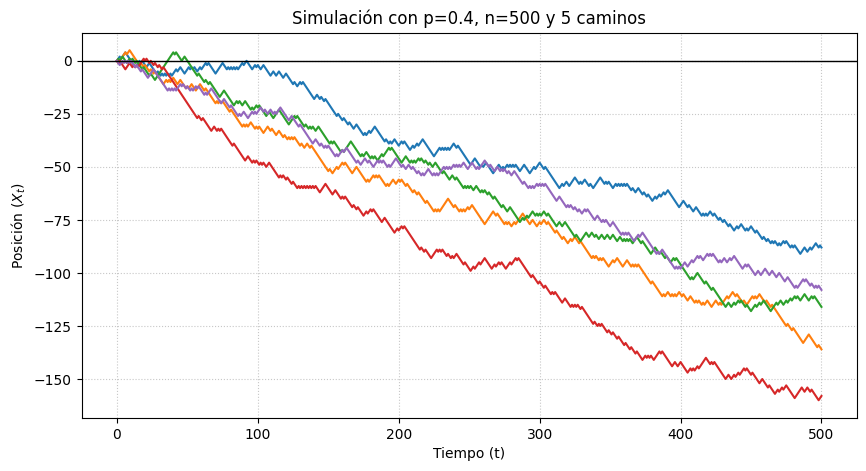

In [ ]:
graficar_PAS(trayectorias, 0.4, 500, 5)

## Visualización 2: diferentes trayectorias del PAS (con media y desviación típica teóricas)

Escribir código para crear las imágenes de las diapositivas 30 ($p=0.5$), 31 ($p=0.75$), 32 ($p=0.95$) del tema 1.

In [ ]:
#Creamos el codigo calculando la media y la desviación típica teóricas

def media_desviacion_PAS(p, n, reps):

    #Usamos la función anterior para generar las trayectorias.
    trayectorias = simular_PAS(p, n, reps)

    t = np.arange(n + 1)

    #Calculamos la media y la desviación típica teóricas
    media = t * (2 * p - 1)
    sigma = np.sqrt(t * 4 * p * (1 - p))

    #Generamos la gráfica
    plt.figure(figsize=(12, 7))

    #Pintamos las trayectorias
    plt.plot(t, trayectorias.T, alpha=0.4, linewidth=1)

    #Representamos la media
    plt.plot(t, media, color='red', linewidth=3, label='Media Teórica')

    #Sombreado para ±1 de desviación típica
    plt.fill_between(t, media - sigma, media + sigma,
                     color='gray', alpha=0.15, label='± 1$\sigma$')

    #Sombreado más claro para ±2 de desviación típica.
    plt.fill_between(t, media - 2 * sigma, media + 2 * sigma,
                     color='gray', alpha=0.1, label='± 2$\sigma$')

    #Configuración estética
    plt.title(f"PAS: Trayectorias vs Predicción Teórica\n(p={p}, n={n}, reps={reps})", fontsize=14)
    plt.xlabel("Tiempo (t)")
    plt.ylabel("Posición ($X_t$)")
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.axhline(0, color='black', lw=1)
    plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_26512/483777387.py:21: SyntaxWarning: invalid escape sequence '\s'
  color='gray', alpha=0.15, label='± 1$\sigma$')
/tmp/ipykernel_26512/483777387.py:25: SyntaxWarning: invalid escape sequence '\s'
  color='gray', alpha=0.1, label='± 2$\sigma$')


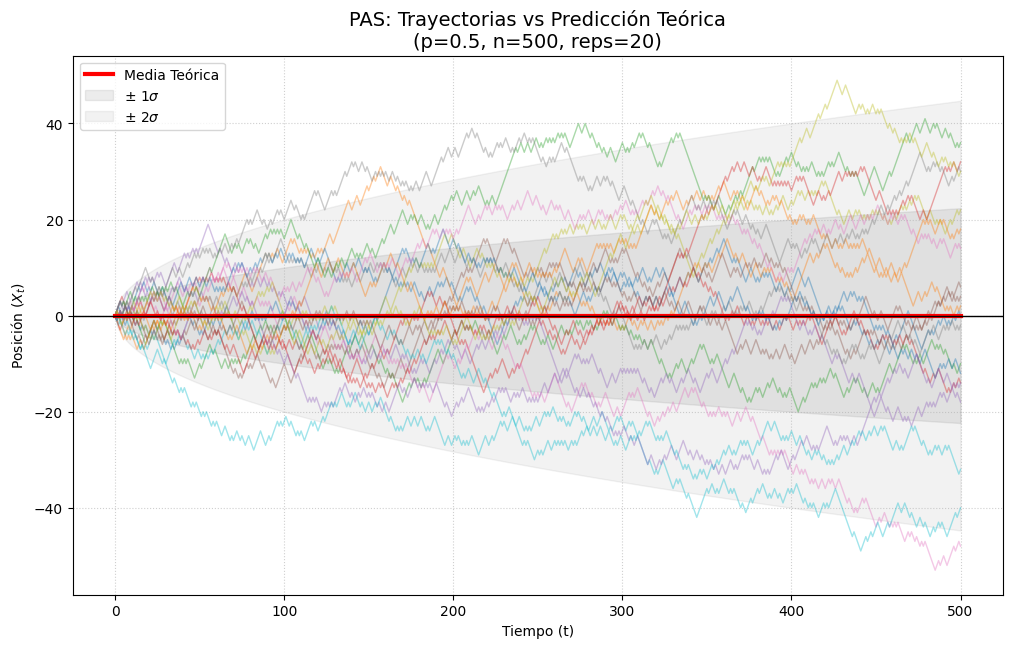

In [ ]:
#DIAPOSITIVA 30
media_desviacion_PAS(0.5,500,20)

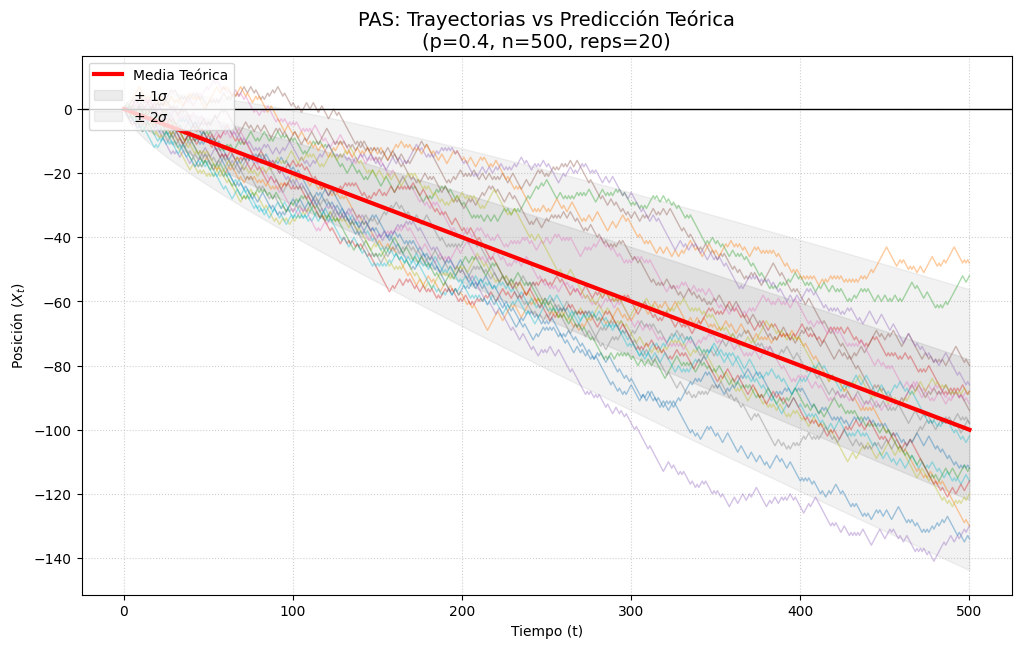

In [ ]:
#DIAPOSITIVA 31
media_desviacion_PAS(0.4,500,20)

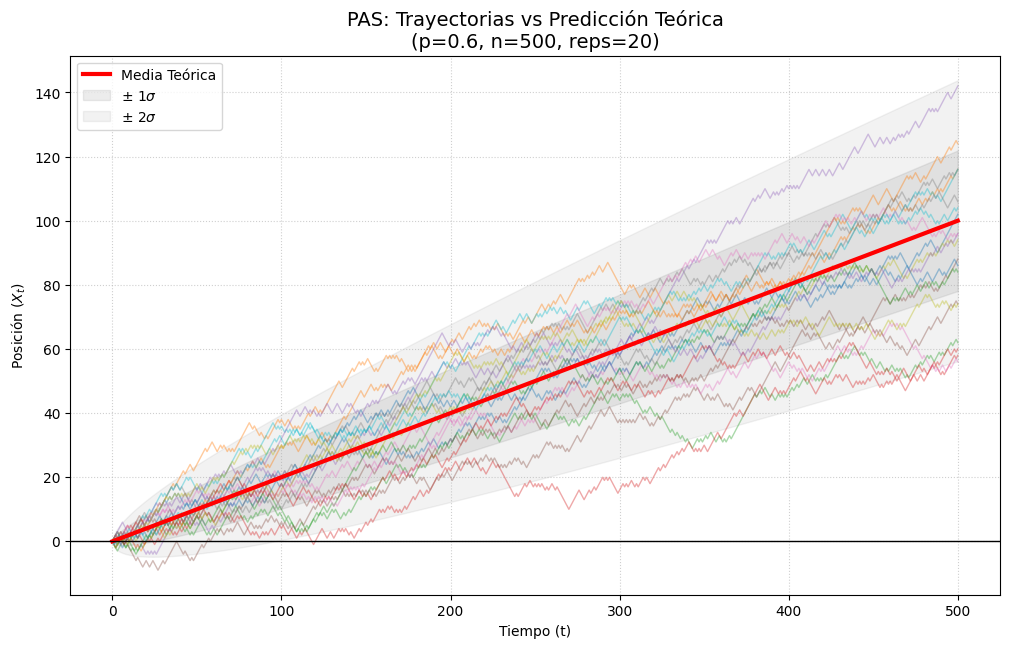

In [ ]:
#DIAPOSITIVA 32
media_desviacion_PAS(0.6,500,20)

## Visualización 3: visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica)

Escribir código para crear la imagen de la diapositiva 35.

In [ ]:
def comparar_PAS(p, n):
    #p: probabilidad de éxito
    #n: número de pasos

    t = np.arange(n + 1)

    #Calculamos la media teórica
    media_teorica = t * (2 * p - 1)

    plt.figure(figsize=(12, 7))

    #Dibujamos la media teórica primero
    plt.plot(t, media_teorica, color='red', linewidth=2, label='Exact', zorder=10)

    #Calculamos las medias para distintos números
    lista_reps = [5, 100, 200, 500, 1000]

    #Definimos una escala de grises para representar las trayectorias
    colores = ['#444444', '#777777', '#999999', '#CCCCCC', '#EEEEEE']

    for reps, color in zip(lista_reps, colores):
        #Generamos las trayectorias
        pasos = np.zeros((reps, n + 1))
        pasos[:, 1:] = np.random.choice([1, -1], size=(reps, n), p=[p, 1-p])
        trayectorias = np.cumsum(pasos, axis=1)

        #Calculamos la media empírica. El resultado es un array de tamaño (n + 1,)
        media_empirica = np.mean(trayectorias, axis=0)

        #Hacemos la gráfica
        plt.plot(t, media_empirica, color=color, label=f'{reps}')


    plt.title("Media y varianza empíricas", loc='left', fontsize=14, fontweight='bold')
    plt.xlabel("t")
    plt.ylabel("$X_t$")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.axhline(0, color='black', lw=0.8)
    plt.legend(loc='upper left')

    plt.show()

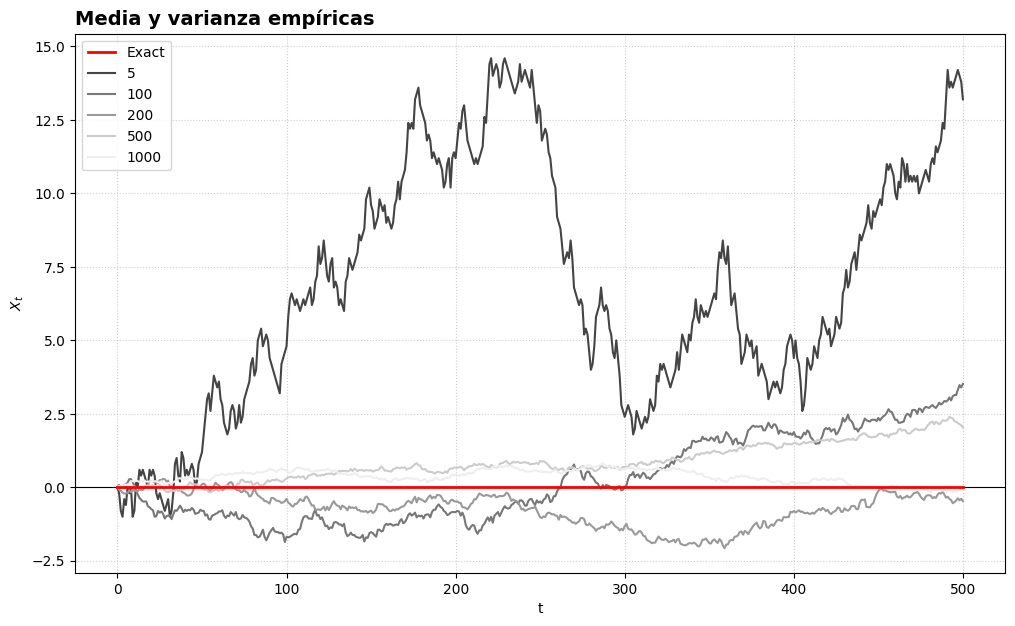

In [ ]:
#DIAPOSITIVA 35
comparar_PAS(0.5, 500)